In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("./data/now_final_3malware.csv")

print("=" * 50)
print("Dataset shape")
print("=" * 50)

print(df.shape)

print("\nColumns:\n")
print(df.columns.tolist())

Dataset shape
(46835, 38)

Columns:

['pcap_id', 'sample_hash', 'label', 'src_ip', 'dst_ip', 'src_port', 'dst_port', 'protocol', 'duration', 'total_bytes', 'total_packets', 'bytes_per_second', 'packets_per_second', 'pkt_len_mean', 'pkt_len_std', 'iat_mean', 'iat_std', 'burstiness', 'burst_count', 'is_complete_handshake', 'has_tls', 'tls_cipher_count', 'tls_ext_count', 'ja4_fingerprint', 'ja4_tls_ver_num', 'ja4_cipher_count', 'ja4_ext_count', 'ja4_sni_present', 'ja4_has_alpn', 'ja4s_fingerprint', 'ja4s_tls_ver_num', 'ja4s_cipher', 'ja4s_ext_count', 'ja3_fingerprint', 'dns_query_count', 'dns_unique_queries', 'http_request_count', 'http_unique_hosts']



Flows per label:

label
Qakbot      11893
bengin      11801
emotet      11646
trickbot    11495
Name: count, dtype: int64


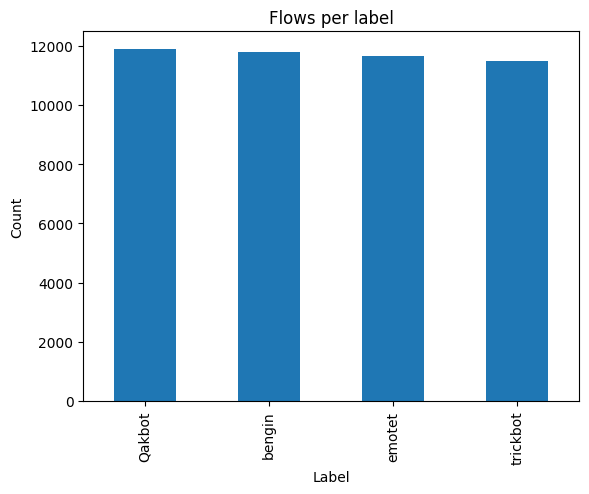

In [2]:
print("\nFlows per label:\n")

print(df["label"].value_counts())

df["label"].value_counts().plot(kind="bar")

plt.title("Flows per label")
plt.xlabel("Label")
plt.ylabel("Count")

plt.show()


Unique JA4 fingerprints per label:

label
Qakbot      27
bengin      27
emotet       9
trickbot     9
Name: ja4_fingerprint, dtype: int64
ja4_fingerprint
t10i120300_d94e65cdb899_5f12c91e28fe    978
t13d1516h2_8daaf6152771_d8a2da3f94cd    770
t12i280600_d943125447b4_a8cc486ca5dc    741
t12d190800_d83cc789557e_7af1ed941c26    711
t12i190700_d83cc789557e_7af1ed941c26    701
t12d210500_b973bfd88a0e_677eed04e9fb    385
t13i190800_9dc949149365_97f8aa674fd9    350
t13d1517h2_8daaf6152771_b6f405a00624    232
t12d1909h2_d83cc789557e_7af1ed941c26    212
t10d070200_487429dcdaa1_94264683603e    204
t13d1812h1_85036bcba153_b26ce05bbdd6    102
t12i190700_d83cc789557e_47617cf24602     99
t12i210400_b973bfd88a0e_677eed04e9fb     99
t12i190700_d83cc789557e_652f19f1cfc7     65
t13d190900_9dc949149365_97f8aa674fd9     65
t13i311000_e8f1e7e78f70_d41ae481755e     53
t12i190600_d83cc789557e_2dae41c691ec     45
t12d1809h2_4b22cbed5bed_7af1ed941c26     45
t12d650700_0dd215169a35_4446390ac224     45
t12d1909h

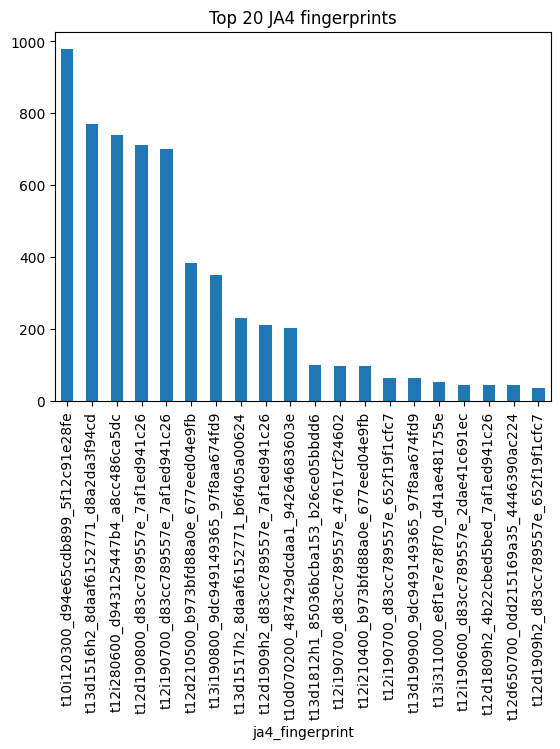

In [3]:
print("\nUnique JA4 fingerprints per label:\n")

print(
    df.groupby("label")["ja4_fingerprint"]
      .nunique()
      .sort_values(ascending=False)
)
top = df["ja4_fingerprint"].value_counts().head(20)

print(top)

top.plot(kind="bar")

plt.title("Top 20 JA4 fingerprints")

plt.show()

has_tls
0    34459
1    12376
Name: count, dtype: int64


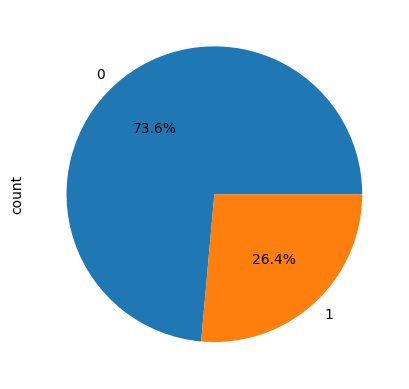

In [4]:
print(df["has_tls"].value_counts())

df["has_tls"].value_counts().plot(kind="pie", autopct="%1.1f%%")

plt.show()

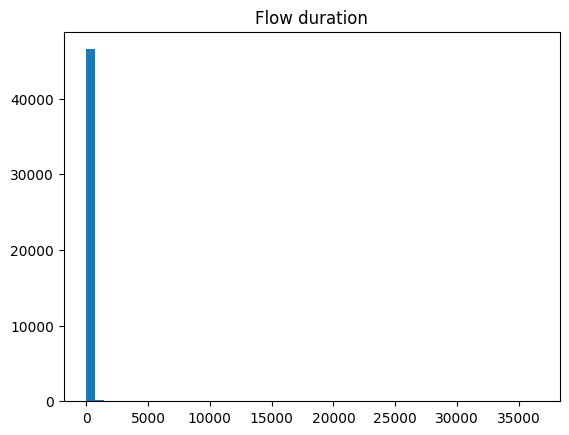

In [5]:
plt.hist(
    df["duration"],
    bins=50
)

plt.title("Flow duration")

plt.show()

In [6]:
missing = df.isnull().sum()

missing = missing[missing > 0]

print(missing)

ja4_fingerprint     40621
ja4s_fingerprint    40672
ja4s_cipher         40672
ja3_fingerprint     40621
dtype: int64


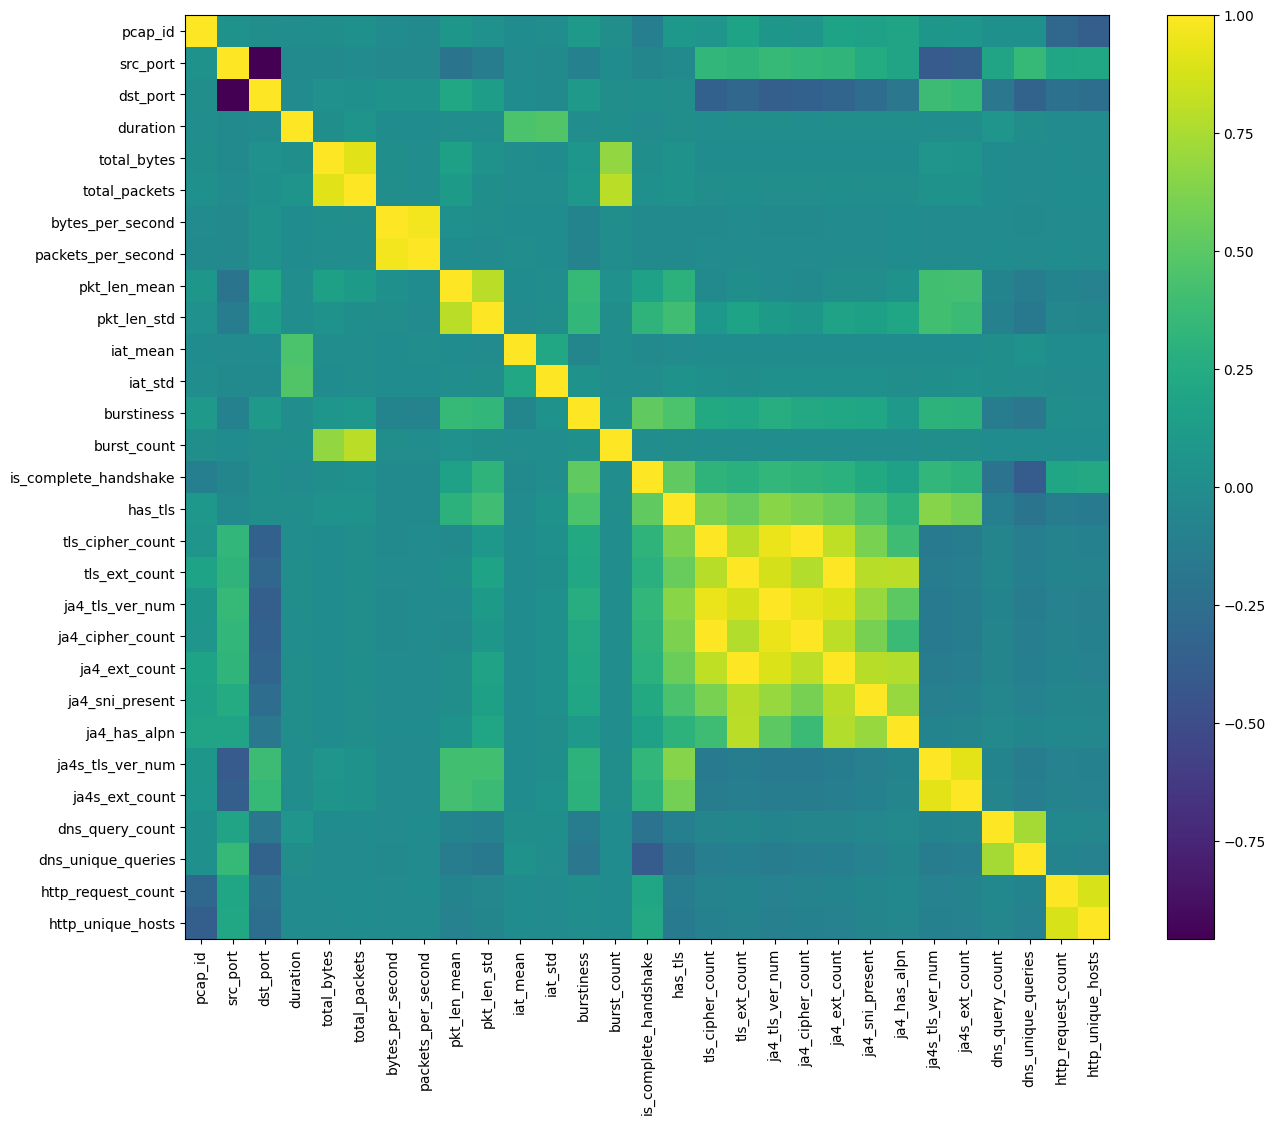

In [7]:
numeric = df.select_dtypes(include=np.number)

corr = numeric.corr()

plt.figure(figsize=(15, 12))

plt.imshow(corr)

plt.colorbar()

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.show()

In [8]:
print(
    df["pcap_id"]
    .value_counts()
)

pcap_id
2     6086
11    5833
22    4886
27    3491
26    3189
17    3049
25    3049
10    1797
18    1657
13    1608
23    1371
6     1368
12    1131
3      854
21     838
14     810
20     744
19     719
9      711
24     701
5      651
15     526
4      518
1      415
7      345
16     267
8      221
Name: count, dtype: int64


In [9]:
numeric_features = [

    "duration",
    "total_bytes",
    "total_packets",
    "bytes_per_second",
    "packets_per_second",
    "pkt_len_mean",
    "pkt_len_std",
    "iat_mean",
    "iat_std",
    "burstiness",
    "burst_count",
    "is_complete_handshake",
    "has_tls",
    "tls_cipher_count",
    "tls_ext_count",
    "ja4_tls_ver_num",
    "ja4_cipher_count",
    "ja4_ext_count",
    "ja4_sni_present",
    "ja4_has_alpn",
    "dns_query_count",
    "dns_unique_queries",
    "http_request_count",
    "http_unique_hosts"
]

In [10]:
features = [
    "duration",
    "total_bytes",
    "total_packets",
    "bytes_per_second",
    "pkt_len_mean",
    "iat_mean",
    "tls_cipher_count",
]

for col in features:
    print("\n", col)
    print(
        df.groupby("label")[col]
          .describe()[["mean", "std"]]
    )


 duration
               mean          std
label                           
Qakbot    89.279165  1056.851196
bengin    34.805006   114.235337
emotet    21.900822   279.318854
trickbot  81.358829  1138.661717

 total_bytes
                  mean           std
label                               
Qakbot    15641.946439  2.042230e+05
bengin    59337.779256  1.315720e+06
emotet    12890.356346  1.843653e+05
trickbot  18631.333797  2.932198e+05

 total_packets
               mean          std
label                           
Qakbot    27.188010   281.417771
bengin    65.258453  1217.865857
emotet    19.607848   170.990396
trickbot  21.853763   192.571225

 bytes_per_second
                   mean           std
label                                
Qakbot     30846.845538  2.585526e+05
bengin     25742.094579  2.231407e+05
emotet    147201.003033  2.339640e+06
trickbot   48267.830831  2.581924e+05

 pkt_len_mean
                mean         std
label                           
Qakbot    209

In [23]:
from sklearn.feature_selection import mutual_info_classif

features = [
    "duration",
    "total_bytes",
    "total_packets",
    "bytes_per_second",
    "packets_per_second",
    "pkt_len_mean",
    "pkt_len_std",
    "iat_mean",
    "iat_std",
    "burstiness",
    "burst_count",
    "is_complete_handshake",
    "has_tls",
    "tls_cipher_count",
    "tls_ext_count",
    "ja4_tls_ver_num",
    "ja4_cipher_count",
    "ja4_ext_count",
    "ja4_sni_present",
    "ja4_has_alpn",
    "ja4s_tls_ver_num",
    "ja4s_ext_count",
    "dns_query_count",
    "dns_unique_queries",
    "http_request_count",
    "http_unique_hosts",
]

scores = mutual_info_classif(
    df[features].fillna(0),
    df["label"]
)

result = (
    pd.DataFrame(
        {
            "feature": features,
            "score": scores
        }
    )
    .sort_values(
        "score",
        ascending=False
    )
)

print(result)

                  feature     score
1             total_bytes  0.551752
5            pkt_len_mean  0.498564
0                duration  0.384035
6             pkt_len_std  0.369414
3        bytes_per_second  0.316250
4      packets_per_second  0.285878
7                iat_mean  0.279567
8                 iat_std  0.248327
9              burstiness  0.208136
14          tls_ext_count  0.178959
17          ja4_ext_count  0.166652
13       tls_cipher_count  0.166262
16       ja4_cipher_count  0.162660
20       ja4s_tls_ver_num  0.122679
15        ja4_tls_ver_num  0.121985
2           total_packets  0.116504
11  is_complete_handshake  0.051550
10            burst_count  0.050634
21         ja4s_ext_count  0.032464
22        dns_query_count  0.019892
18        ja4_sni_present  0.019730
24     http_request_count  0.018281
23     dns_unique_queries  0.016199
19           ja4_has_alpn  0.015590
25      http_unique_hosts  0.013749
12                has_tls  0.010558


In [24]:
print(
    df.groupby("label")["pcap_id"].nunique()
)
print(df.groupby(["label", "pcap_id"]).size())

label
Qakbot      6
bengin      5
emotet      7
trickbot    9
Name: pcap_id, dtype: int64
label     pcap_id
Qakbot    17         1000
          18         1000
          19          719
          20          744
          21          838
          22         1000
bengin    23         1000
          24          701
          25         1000
          26         1000
          27         1000
emotet    7           345
          8           221
          9           711
          10         1000
          11         1000
          12         1000
          13         1000
trickbot  1           415
          2          1000
          3           854
          4           518
          5           651
          6          1000
          14          810
          15          526
          16          267
dtype: int64


In [25]:
df["ja4s_fingerprint"].fillna("").str.len().describe()

count    21320.000000
mean         3.784006
std          8.960201
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         25.000000
Name: ja4s_fingerprint, dtype: float64

In [27]:
print(df.groupby("label")["pcap_id"].unique())

label
Qakbot            [17, 18, 19, 20, 21, 22]
bengin                [23, 24, 25, 26, 27]
emotet           [7, 8, 9, 10, 11, 12, 13]
trickbot    [1, 2, 3, 4, 5, 6, 14, 15, 16]
Name: pcap_id, dtype: object


In [28]:
print(
    df.groupby("label")["pcap_id"].nunique()
)
print(df.groupby(["label", "pcap_id"]).size())

label
Qakbot      6
bengin      5
emotet      7
trickbot    9
Name: pcap_id, dtype: int64
label     pcap_id
Qakbot    17         1000
          18         1000
          19          719
          20          744
          21          838
          22         1000
bengin    23         1000
          24          701
          25         1000
          26         1000
          27         1000
emotet    7           345
          8           221
          9           711
          10         1000
          11         1000
          12         1000
          13         1000
trickbot  1           415
          2          1000
          3           854
          4           518
          5           651
          6          1000
          14          810
          15          526
          16          267
dtype: int64


In [17]:
import pandas as pd
import numpy as np

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


# ==========================================
# FEATURES
# ==========================================

# ==========================================
# FEATURES (low-performing features removed)
# ==========================================

features = [

    # Flow statistics
    "duration",
    "total_bytes",
    "total_packets",

    "bytes_per_second",
    "packets_per_second",

    # Packet statistics
    "pkt_len_mean",
    "pkt_len_std",

    # Timing
    "iat_mean",
    "iat_std",

    # Burst features
    "burstiness",
    "burst_count",

    # Handshake
    "is_complete_handshake",

    # TLS features
    "tls_cipher_count",
    "tls_ext_count",

    # JA4 numeric features
    "ja4_tls_ver_num",
    "ja4_cipher_count",
    "ja4_ext_count",
]


# ==========================================
# PREPROCESSING
# ==========================================

X = df[features].fillna(0)

label_encoder = LabelEncoder()

y = label_encoder.fit_transform(
    df["label"]
)

groups = df["pcap_id"]


# ==========================================
# SPLIT BY PCAP
# ==========================================

splitter = GroupShuffleSplit(

    n_splits=1,
    test_size=0.2,
    random_state=42

)

train_idx, test_idx = next(

    splitter.split(
        X,
        y,
        groups=groups
    )

)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y[train_idx]
y_test = y[test_idx]


print("\nTrain labels:")

print(
    df.iloc[train_idx]["label"]
    .value_counts()
)

print("\nTest labels:")

print(
    df.iloc[test_idx]["label"]
    .value_counts()
)


# ==========================================
# SCALE FEATURES
# ==========================================

scaler = StandardScaler()

X_train = scaler.fit_transform(
    X_train
)

X_test = scaler.transform(
    X_test
)


# ==========================================
# MODELS
# ==========================================

models = {

    "Random Forest": RandomForestClassifier(

        n_estimators=300,
        max_depth=20,
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(

        n_estimators=300,
        max_depth=8,

        learning_rate=0.05,

        subsample=0.8,

        colsample_bytree=0.8,

        random_state=42
    ),

    "LightGBM": LGBMClassifier(

        n_estimators=300,

        learning_rate=0.05,

        num_leaves=31,

        random_state=42
    )

}


# ==========================================
# TRAIN AND TEST
# ==========================================

for name, model in models.items():

    print("\n")
    print("=" * 60)

    print(name)

    print("=" * 60)

    model.fit(

        X_train,
        y_train

    )

    pred = model.predict(
        X_test
    )

    print("\nClassification report:\n")

    print(

        classification_report(

            y_test,

            pred,

            target_names=label_encoder.classes_,

            digits=4

        )

    )

    print("\nConfusion matrix:\n")

    print(

        confusion_matrix(

            y_test,
            pred

        )

    )


Train labels:
label
trickbot    4816
bengin      4701
Qakbot      4301
emotet      2566
Name: count, dtype: int64

Test labels:
label
emotet      2711
trickbot    1225
Qakbot      1000
Name: count, dtype: int64


Random Forest

Classification report:

              precision    recall  f1-score   support

      Qakbot     0.3759    0.7530    0.5015      1000
      bengin     0.0000    0.0000    0.0000         0
      emotet     0.7803    0.3707    0.5026      2711
    trickbot     0.6478    0.5527    0.5965      1225

    accuracy                         0.4933      4936
   macro avg     0.4510    0.4191    0.4001      4936
weighted avg     0.6655    0.4933    0.5257      4936


Confusion matrix:

[[ 753   47  114   86]
 [   0    0    0    0]
 [1018  406 1005  282]
 [ 232  147  169  677]]


XGBoost


c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} i


Classification report:

              precision    recall  f1-score   support

      Qakbot     0.3933    0.7700    0.5206      1000
      bengin     0.0000    0.0000    0.0000         0
      emotet     0.7974    0.3862    0.5204      2711
    trickbot     0.6370    0.5559    0.5937      1225

    accuracy                         0.5061      4936
   macro avg     0.4569    0.4280    0.4087      4936
weighted avg     0.6757    0.5061    0.5386      4936


Confusion matrix:

[[ 770   47   96   87]
 [   0    0    0    0]
 [ 946  417 1047  301]
 [ 242  132  170  681]]


LightGBM
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000964 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2687
[LightGBM] [Info] Number of data points in the train set: 16384, number of used features: 17
[LightGBM] [Info] Start training from score -1.337458
[LightGBM] [Info] Start training from score -1.248530
[LightGBM] [Info] S

c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} i


Classification report:

              precision    recall  f1-score   support

      Qakbot     0.3790    0.7670    0.5073      1000
      bengin     0.0000    0.0000    0.0000         0
      emotet     0.7951    0.3692    0.5043      2711
    trickbot     0.6369    0.5469    0.5885      1225

    accuracy                         0.4939      4936
   macro avg     0.4527    0.4208    0.4000      4936
weighted avg     0.6715    0.4939    0.5258      4936


Confusion matrix:

[[ 767   48   94   91]
 [   0    0    0    0]
 [ 996  423 1001  291]
 [ 261  130  164  670]]


c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} i

In [18]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier




# ==========================================================
# FEATURES
# ==========================================================

features = [

    "duration",
    "total_bytes",
    "total_packets",

    "bytes_per_second",
    "packets_per_second",

    "pkt_len_mean",
    "pkt_len_std",

    "iat_mean",
    "iat_std",

    "burstiness",
    "burst_count",

    "is_complete_handshake",

    "tls_cipher_count",
    "tls_ext_count",

    "ja4_tls_ver_num",
    "ja4_cipher_count",
    "ja4_ext_count",

]


# ==========================================================
# PREPROCESS
# ==========================================================

X = df[features].fillna(0)

label_encoder = LabelEncoder()

y = label_encoder.fit_transform(
    df["label"]
)

print("\nClasses:")

print(
    label_encoder.classes_
)


# ==========================================================
# RANDOM SPLIT
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42,

    stratify=y,

    shuffle=True

)


# ==========================================================
# SHOW LABEL DISTRIBUTION
# ==========================================================

train_labels = label_encoder.inverse_transform(
    y_train
)

test_labels = label_encoder.inverse_transform(
    y_test
)

print("\nTrain size:", len(X_train))
print("Test size:", len(X_test))

print("\nTrain labels:")

print(
    pd.Series(
        train_labels
    ).value_counts()
)

print("\nTest labels:")

print(
    pd.Series(
        test_labels
    ).value_counts()
)


# ==========================================================
# SCALE
# ==========================================================

scaler = StandardScaler()

X_train = scaler.fit_transform(
    X_train
)

X_test = scaler.transform(
    X_test
)


# ==========================================================
# MODELS
# ==========================================================

models = {

    "Random Forest": RandomForestClassifier(

        n_estimators=300,

        max_depth=20,

        random_state=42,

        n_jobs=-1

    ),

    "XGBoost": XGBClassifier(

        n_estimators=300,

        max_depth=8,

        learning_rate=0.05,

        subsample=0.8,

        colsample_bytree=0.8,

        random_state=42

    ),

    "LightGBM": LGBMClassifier(

        n_estimators=300,

        learning_rate=0.05,

        num_leaves=31,

        random_state=42

    )

}


# ==========================================================
# TRAIN + TEST
# ==========================================================

for name, model in models.items():

    print("\n")
    print("=" * 60)

    print(name)

    print("=" * 60)

    model.fit(

        X_train,
        y_train

    )

    pred = model.predict(
        X_test
    )

    print("\nClassification report:\n")

    print(

        classification_report(

            y_test,

            pred,

            target_names=label_encoder.classes_,

            digits=4

        )

    )

    print("\nConfusion matrix:\n")

    print(

        confusion_matrix(

            y_test,
            pred

        )

    )


Classes:
['Qakbot' 'bengin' 'emotet' 'trickbot']

Train size: 17056
Test size: 4264

Train labels:
trickbot    4833
Qakbot      4241
emotet      4221
bengin      3761
Name: count, dtype: int64

Test labels:
trickbot    1208
Qakbot      1060
emotet      1056
bengin       940
Name: count, dtype: int64


Random Forest

Classification report:

              precision    recall  f1-score   support

      Qakbot     0.7848    0.7708    0.7777      1060
      bengin     0.9061    0.7904    0.8443       940
      emotet     0.7189    0.8040    0.7591      1056
    trickbot     0.8699    0.8800    0.8749      1208

    accuracy                         0.8143      4264
   macro avg     0.8199    0.8113    0.8140      4264
weighted avg     0.8193    0.8143    0.8153      4264


Confusion matrix:

[[ 817   34  147   62]
 [  53  743  112   32]
 [ 117   25  849   65]
 [  54   18   73 1063]]


XGBoost

Classification report:

              precision    recall  f1-score   support

      Qakbot     0.

In [19]:
import pandas as pd
import numpy as np
import tensorflow as tf

from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import StratifiedGroupKFold


MAX_LEN = 64          # JA4 fingerprint max length
JA3_MAX_LEN = 32      # JA3 is always a 32-char md5 hex digest
EMBEDDING_DIM = 32

MAX_FLOWS_PER_PCAP = 1000

# ------------------------------------------------------------------
# KEY CHANGE #1: the model is only ever trained/fit on these 3 classes.
# "qakbot" is treated as a completely unseen malware family -- it must
# never appear in label_encoder.classes_, never be used to fit the
# tokenizer/scaler/one-hot-encoder, and never be used to train the model.
# It is only used at the very end, as a held-out demo set, to check that
# the model correctly refuses to classify it (falls back to "unknown").
# ------------------------------------------------------------------
KNOWN_CLASSES = ["bengin", "Qakbot", "emotet"]
UNKNOWN_CLASS = "trickbot"

# Softmax confidence threshold: if the model's top class probability is
# below this, we call the flow "unknown_malware" instead of trusting the
# argmax. Tune this on the known-class validation folds (see below) --
# it should be as high as possible while still keeping accuracy on known
# classes acceptable.
UNKNOWN_THRESHOLD = 0.80

NUMERIC_FEATURES = [
    "duration",
    "total_bytes",
    "total_packets",
    "bytes_per_second",
    "packets_per_second",
    "pkt_len_mean",
    "pkt_len_std",
    "iat_mean",
    "iat_std",
    "burstiness",
    "burst_count",
    "is_complete_handshake",
    "has_tls",
    "tls_cipher_count",
    "tls_ext_count",
    "ja4_tls_ver_num",
    "ja4_cipher_count",
    "ja4_ext_count",
    "ja4_sni_present",
    "ja4_has_alpn",
    "dns_query_count",
    "dns_unique_queries",
    "http_request_count",
    "http_unique_hosts",
]

CATEGORICAL_FEATURES = ["protocol"]


# ============================================================
# LIMIT FLOWS PER PCAP (applied to the whole dataset, including qakbot --
# this is just downsampling per capture, it doesn't leak any labels)
# ============================================================

sampled_idx_per_group = df.groupby("pcap_id").apply(
    lambda x: x.sample(n=min(len(x), MAX_FLOWS_PER_PCAP), random_state=42).index
)
all_sampled_idx = np.concatenate(sampled_idx_per_group.values)
df = df.loc[all_sampled_idx].reset_index(drop=True)

print("Rows after balancing:", len(df))


# ============================================================
# KEY CHANGE #2: split off qakbot BEFORE anything else is fit.
# df_known -> used for CV training/testing (benign/trickbot/emotet only)
# df_unknown -> qakbot only, held out completely, used only for the final
#               "does the model say UNKNOWN" demo
# ============================================================

df_known = df[df["label"].isin(KNOWN_CLASSES)].reset_index(drop=True)
df_unknown = df[df["label"] == UNKNOWN_CLASS].reset_index(drop=True)

print("\nKnown-class rows (benign/trickbot/emotet):", len(df_known))
print("Held-out unknown rows (qakbot):", len(df_unknown))
print("Known-class label counts:\n", df_known["label"].value_counts())


# ============================================================
# TOKENIZER (for ja4_fingerprint / ja3_fingerprint text branches)
# ============================================================

class FingerprintTokenizer:
    """Generic char-level tokenizer, reused for both ja4_fingerprint and
    ja3_fingerprint (each gets its own instance/vocabulary/max_len)."""

    def __init__(self, max_len):
        self.max_len = max_len
        self.char_to_id = {
            "<PAD>": 0,
            "<UNK>": 1,
        }

    def fit(self, texts):
        for text in texts:
            text = "" if pd.isna(text) else str(text)
            for ch in text:
                if ch not in self.char_to_id:
                    self.char_to_id[ch] = len(self.char_to_id)

    def encode(self, text):
        text = "" if pd.isna(text) else str(text)
        ids = [
            self.char_to_id.get(ch, self.char_to_id["<UNK>"])
            for ch in text
        ]
        if len(ids) > self.max_len:
            ids = ids[:self.max_len]
        padded = np.zeros(self.max_len, dtype=np.int32)
        padded[:len(ids)] = ids
        return padded


# ============================================================
# ENCODE LABELS -- fit ONLY on the 3 known classes, so the model literally
# has no output neuron for qakbot. This is what forces qakbot predictions
# to come out as low-confidence spread across benign/trickbot/emotet,
# which the threshold step below turns into "unknown_malware".
# ============================================================

label_encoder = LabelEncoder()
label_encoder.fit(KNOWN_CLASSES)
y_known = label_encoder.transform(df_known["label"])

print("\nKnown classes (model outputs):")
print(label_encoder.classes_)


# ============================================================
# SPLIT USING PCAP ID, KNOWN CLASSES ONLY
# (done BEFORE fitting any tokenizer/scaler/encoder, so nothing about the
# test set -- or qakbot -- leaks into what gets fit on train)
# ============================================================

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

accuracies = []
unknown_detection_rates = []

train_idx, test_idx = next(
    splitter.split(
        df_known,
        y_known,
        groups=df_known["pcap_id"]
    )
)

print(f"\n=========================== Fold {fold} ===========================")

df_train = df_known.iloc[train_idx].reset_index(drop=True)
df_test = df_known.iloc[test_idx].reset_index(drop=True)

y_train = y_known[train_idx]
y_test = y_known[test_idx]

print("\nTrain size:", len(df_train))
print("Test size:", len(df_test))

print("\nTrain PCAP count:", df_train["pcap_id"].nunique())
print("Test PCAP count:", df_test["pcap_id"].nunique())

print("\nTrain labels:\n", df_train["label"].value_counts())
print("\nTest labels:\n", df_test["label"].value_counts())

# sanity check: qakbot must never appear here
assert not df_train["label"].isin([UNKNOWN_CLASS]).any()
assert not df_test["label"].isin([UNKNOWN_CLASS]).any()

# ============================================================
# JA4 TEXT BRANCH: fit tokenizer on TRAIN ONLY, encode train/test/qakbot
# ============================================================

ja4_tokenizer = FingerprintTokenizer(max_len=MAX_LEN)
ja4_tokenizer.fit(df_train["ja4_fingerprint"].fillna("").astype(str).tolist())

X_ja4_train = np.vstack(df_train["ja4_fingerprint"].apply(ja4_tokenizer.encode))
X_ja4_test = np.vstack(df_test["ja4_fingerprint"].apply(ja4_tokenizer.encode))
X_ja4_unknown = np.vstack(df_unknown["ja4_fingerprint"].apply(ja4_tokenizer.encode))

print("\nJA4 encoded shape (train):", X_ja4_train.shape)
print("JA4 vocabulary size:", len(ja4_tokenizer.char_to_id))

# ============================================================
# JA3 TEXT BRANCH
# ============================================================

ja3_tokenizer = FingerprintTokenizer(max_len=JA3_MAX_LEN)
ja3_tokenizer.fit(df_train["ja3_fingerprint"].fillna("").astype(str).tolist())

X_ja3_train = np.vstack(df_train["ja3_fingerprint"].apply(ja3_tokenizer.encode))
X_ja3_test = np.vstack(df_test["ja3_fingerprint"].apply(ja3_tokenizer.encode))
X_ja3_unknown = np.vstack(df_unknown["ja3_fingerprint"].apply(ja3_tokenizer.encode))

print("\nJA3 encoded shape (train):", X_ja3_train.shape)
print("JA3 vocabulary size:", len(ja3_tokenizer.char_to_id))

# ============================================================
# NUMERIC / CATEGORICAL BRANCH -- fit scaler/encoder on TRAIN ONLY,
# transform test AND qakbot (never fit on either)
# ============================================================

train_numeric_df = df_train[NUMERIC_FEATURES].apply(pd.to_numeric, errors="coerce").fillna(0.0)
test_numeric_df = df_test[NUMERIC_FEATURES].apply(pd.to_numeric, errors="coerce").fillna(0.0)
unknown_numeric_df = df_unknown[NUMERIC_FEATURES].apply(pd.to_numeric, errors="coerce").fillna(0.0)

scaler = StandardScaler()
X_num_train = scaler.fit_transform(train_numeric_df.values)
X_num_test = scaler.transform(test_numeric_df.values)
X_num_unknown = scaler.transform(unknown_numeric_df.values)

cat_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
train_cat_df = df_train[CATEGORICAL_FEATURES].fillna("UNKNOWN").astype(str)
test_cat_df = df_test[CATEGORICAL_FEATURES].fillna("UNKNOWN").astype(str)
unknown_cat_df = df_unknown[CATEGORICAL_FEATURES].fillna("UNKNOWN").astype(str)

X_cat_train = cat_encoder.fit_transform(train_cat_df.values)
X_cat_test = cat_encoder.transform(test_cat_df.values)
X_cat_unknown = cat_encoder.transform(unknown_cat_df.values)

X_num_train = np.hstack([X_num_train, X_cat_train]).astype(np.float32)
X_num_test = np.hstack([X_num_test, X_cat_test]).astype(np.float32)
X_num_unknown = np.hstack([X_num_unknown, X_cat_unknown]).astype(np.float32)

NUM_INPUT_DIM = X_num_train.shape[1]
print("\nNumeric/categorical feature vector size:", NUM_INPUT_DIM)

# ============================================================
# CLASS WEIGHTS
# ============================================================

class_weight_values = compute_class_weight(
    "balanced",
    classes=np.unique(y_train),
    y=y_train,
)
class_weight = {i: w for i, w in enumerate(class_weight_values)}
print("\nClass weights:", class_weight)

# ============================================================
# MODEL: three input branches concatenated before the classifier head.
# Output layer has exactly len(KNOWN_CLASSES) = 3 units -- there is
# no "qakbot" neuron, by construction.
# ============================================================

ja4_input = tf.keras.layers.Input(shape=(MAX_LEN,), name="ja4_input")
x = tf.keras.layers.Embedding(input_dim=len(ja4_tokenizer.char_to_id), output_dim=EMBEDDING_DIM)(ja4_input)
x = tf.keras.layers.Conv1D(filters=64, kernel_size=5, padding="same", activation="relu")(x)
x = tf.keras.layers.MaxPooling1D(pool_size=2)(x)
x = tf.keras.layers.Conv1D(filters=128, kernel_size=3, padding="same", activation="relu")(x)
x = tf.keras.layers.GlobalMaxPooling1D()(x)
ja4_branch_out = tf.keras.layers.Dense(64, activation="relu")(x)

ja3_input = tf.keras.layers.Input(shape=(JA3_MAX_LEN,), name="ja3_input")
j3 = tf.keras.layers.Embedding(input_dim=len(ja3_tokenizer.char_to_id), output_dim=EMBEDDING_DIM)(ja3_input)
j3 = tf.keras.layers.Conv1D(filters=64, kernel_size=5, padding="same", activation="relu")(j3)
j3 = tf.keras.layers.MaxPooling1D(pool_size=2)(j3)
j3 = tf.keras.layers.Conv1D(filters=128, kernel_size=3, padding="same", activation="relu")(j3)
j3 = tf.keras.layers.GlobalMaxPooling1D()(j3)
ja3_branch_out = tf.keras.layers.Dense(64, activation="relu")(j3)

numeric_input = tf.keras.layers.Input(shape=(NUM_INPUT_DIM,), name="numeric_input")
n = tf.keras.layers.Dense(64, activation="relu")(numeric_input)
n = tf.keras.layers.Dropout(0.3)(n)
numeric_branch_out = tf.keras.layers.Dense(32, activation="relu")(n)

combined = tf.keras.layers.Concatenate()([ja4_branch_out, ja3_branch_out, numeric_branch_out])
combined = tf.keras.layers.Dense(64, activation="relu")(combined)
combined = tf.keras.layers.Dropout(0.3)(combined)
output = tf.keras.layers.Dense(len(label_encoder.classes_), activation="softmax")(combined)

model = tf.keras.Model(inputs=[ja4_input, ja3_input, numeric_input], outputs=output)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()

# ============================================================
# TRAIN (only ever sees benign/trickbot/emotet)
# ============================================================

history = model.fit(
    {"ja4_input": X_ja4_train, "ja3_input": X_ja3_train, "numeric_input": X_num_train},
    y_train,
    validation_data=(
        {"ja4_input": X_ja4_test, "ja3_input": X_ja3_test, "numeric_input": X_num_test},
        y_test,
    ),
    epochs=10,
    batch_size=128,
    class_weight=class_weight,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_accuracy",
            patience=3,
            restore_best_weights=True,
        )
    ],
)

# ============================================================
# EVALUATE ON KNOWN CLASSES (normal in-distribution test set)
# ============================================================

probs_test = model.predict({"ja4_input": X_ja4_test, "ja3_input": X_ja3_test, "numeric_input": X_num_test})
pred_test = np.argmax(probs_test, axis=1)

print("\nClassification report (known classes):\n")
print(classification_report(
y_test,
pred_test,
labels=np.arange(len(label_encoder.classes_)),
target_names=label_encoder.classes_,
digits=4,
zero_division=0
))
print("\nConfusion matrix (known classes):\n")
print(confusion_matrix(y_test, pred_test))

acc = accuracy_score(y_test, pred_test)
accuracies.append(acc)
print(f"Fold {fold} known-class accuracy: {acc:.4f}")

# ============================================================
# KEY CHANGE #3 -- THE DEMO: qakbot was NEVER used to fit the
# tokenizer, scaler, encoder, or model. We run it through the trained
# model, take the softmax max-probability as a confidence score, and
# anything below UNKNOWN_THRESHOLD gets relabeled "unknown_malware"
# instead of one of benign/trickbot/emotet. Since the model has never
# seen qakbot's fingerprint/behavioral pattern, its softmax output
# should be spread out (low max confidence) rather than sharply
# peaked -- that's exactly what the threshold is catching.
# ============================================================

if len(df_unknown) > 0:
    probs_unknown = model.predict(
        {"ja4_input": X_ja4_unknown, "ja3_input": X_ja3_unknown, "numeric_input": X_num_unknown}
    )
    max_conf_unknown = np.max(probs_unknown, axis=1)
    pred_unknown_idx = np.argmax(probs_unknown, axis=1)

    pred_unknown_labels = np.where(
        max_conf_unknown < UNKNOWN_THRESHOLD,
        "unknown_malware",
        label_encoder.inverse_transform(pred_unknown_idx),
    )

    detection_rate = np.mean(pred_unknown_labels == "unknown_malware")
    unknown_detection_rates.append(detection_rate)

    print(f"\n--- QAKBOT (held-out unknown) demo, fold {fold} ---")
    print("Qakbot flows evaluated:", len(df_unknown))
    print("Mean top-class confidence on qakbot:", max_conf_unknown.mean().round(4))
    print(f"Flagged as 'unknown_malware' (threshold={UNKNOWN_THRESHOLD}): "
            f"{detection_rate*100:.2f}% ({int(detection_rate*len(df_unknown))}/{len(df_unknown)})")
    print("Sample of what the model would have guessed instead (if forced to pick a known class):")
    guessed_known = label_encoder.inverse_transform(pred_unknown_idx)
    print(pd.Series(guessed_known).value_counts())

print("\n==========================")
print(f"Mean known-class accuracy: {np.mean(accuracies):.4f}")
print(f"Std known-class accuracy : {np.std(accuracies):.4f}")
if unknown_detection_rates:
    print(f"Mean qakbot 'unknown' detection rate: {np.mean(unknown_detection_rates)*100:.2f}%")
    print(f"Std  qakbot 'unknown' detection rate: {np.std(unknown_detection_rates)*100:.2f}%")

C:\Users\HP\AppData\Local\Temp\ipykernel_15668\895776059.py:71: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled_idx_per_group = df.groupby("pcap_id").apply(


Rows after balancing: 21320

Known-class rows (benign/trickbot/emotet): 15279
Held-out unknown rows (qakbot): 6041
Known-class label counts:
 label
Qakbot    5301
emotet    5277
bengin    4701
Name: count, dtype: int64

Known classes (model outputs):
['Qakbot' 'bengin' 'emotet']

=========================== Fold 5 ===========================

Train size: 12713
Test size: 2566

Train PCAP count: 14
Test PCAP count: 4

Train labels:
 label
bengin    4701
Qakbot    4301
emotet    3711
Name: count, dtype: int64

Test labels:
 label
emotet    1566
Qakbot    1000
Name: count, dtype: int64

JA4 encoded shape (train): (12713, 64)
JA4 vocabulary size: 22

JA3 encoded shape (train): (12713, 32)
JA3 vocabulary size: 18

Numeric/categorical feature vector size: 27

Class weights: {0: np.float64(0.9852747423079904), 1: np.float64(0.9014394100545983), 2: np.float64(1.1419204167789454)}


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ ja4_input           │ (None, 64)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ja3_input           │ (None, 32)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_10        │ (None, 64, 32)    │        704 │ ja4_input[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_11        │ (None, 32, 32)    │        576 │ ja3_input[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_20 (Conv1D)  │ (None, 64, 64)    │     10,304 │ embedding_10[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_22 (Conv1D)  │ (None, 32, 64)    │     10,304 │ embedding_11[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_10    │ (None, 32, 64)    │          0 │ conv1d_20[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_11    │ (None, 16, 64)    │          0 │ conv1d_22[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ numeric_input       │ (None, 27)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_21 (Conv1D)  │ (None, 32, 128)   │     24,704 │ max_pooling1d_10… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_23 (Conv1D)  │ (None, 16, 128)   │     24,704 │ max_pooling1d_11… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_32 (Dense)    │ (None, 64)        │      1,792 │ numeric_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_21[0][0]   │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_23[0][0]   │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 64)        │          0 │ dense_32[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_30 (Dense)    │ (None, 64)        │      8,256 │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_31 (Dense)    │ (None, 64)        │      8,256 │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_33 (Dense)    │ (None, 32)        │      2,080 │ dropout_10[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_5       │ (None, 160)       │          0 │ dense_30[0][0],   │
│ (Concatenate)       │                   │            │ dense_31[0][0],   │
│                     │                   │            │ dense_33[0][0]  

 Total params: 102,179 (399.14 KB)

 Trainable params: 102,179 (399.14 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 0.5475 - loss: 0.9218 - val_accuracy: 0.5269 - val_loss: 1.2237
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.6231 - loss: 0.7945 - val_accuracy: 0.5573 - val_loss: 1.2650
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.6336 - loss: 0.7638 - val_accuracy: 0.5608 - val_loss: 1.3166
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.6461 - loss: 0.7434 - val_accuracy: 0.5284 - val_loss: 1.3938
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.6572 - loss: 0.7297 - val_accuracy: 0.5413 - val_loss: 1.4216
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.6578 - loss: 0.7169 - val_accuracy: 0.5483 - val_loss: 1.4950
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step

Classification report (known classes):

              precision    recall  f1-score   support

      Qakbot     0.5479    0.6180    0.5808      1000
      bengin     0.0000    0.0000   

In [20]:
print("Train:")
print(df_train["label"].value_counts())

print("\nTest:")
print(df_test["label"].value_counts())

Train:
label
bengin    4701
Qakbot    4301
emotet    3711
Name: count, dtype: int64

Test:
label
emotet    1566
Qakbot    1000
Name: count, dtype: int64


In [21]:
print(
    df[df["label"] == "trickbot"]
    .groupby("pcap_id")
    .size()
    .sort_values(ascending=False)
)
print(len(df[df["label"] == "Qakbot"]))

pcap_id
2     1000
6     1000
3      854
14     810
5      651
15     526
4      518
1      415
16     267
dtype: int64
5301
